# Final Portfolio Strategy Comparison

This notebook compares the benchmark and optimized portfolio strategies over a
common out-of-sample period.

The representative strategies include:

- SPY and QQQ;
- Global minimum variance;
- Selected mean–variance portfolios;
- Selected CVaR portfolios;
- The selected relaxed-SSD portfolio.

All strategies are evaluated using the same daily observations. The comparison
reports final wealth, CAGR, annualized volatility, Sharpe ratio, maximum
drawdown, daily 95% VaR, and daily 95% CVaR.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

sns.set_theme(style="whitegrid")

TRADING_DAYS = 252

BACKTEST_START = pd.Timestamp(
    "2010-04-12"
)

BACKTEST_END = pd.Timestamp(
    "2020-04-01"
)

RISK_FREE_RATE = 0.0

In [14]:
current_directory = Path.cwd()

if (current_directory / "data").exists():
    PROJECT_ROOT = current_directory

elif (current_directory.parent / "data").exists():
    PROJECT_ROOT = current_directory.parent

else:
    raise FileNotFoundError(
        "Could not locate the project root. "
        "Run this notebook from the project root "
        "or from the notebooks directory."
    )

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "etf_adjusted_close.csv"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

RESULTS_DIR.mkdir(
    exist_ok=True
)

print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Results directory:",
    RESULTS_DIR,
)

Project root: /Users/yyi/Projects/Portfolio optimization
Results directory: /Users/yyi/Projects/Portfolio optimization/results


## Load Benchmark and Optimized-Strategy Returns

SPY and QQQ returns are reconstructed directly from adjusted prices.

The optimized portfolio returns are loaded from the CSV files exported by the
previous notebooks. Missing files are reported explicitly and will not prevent
the remaining strategies from being compared.

In [15]:
prices = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=["Date"],
)

asset_returns = (
    prices
    .pct_change(fill_method=None)
    .dropna(how="all")
)

benchmark_returns = asset_returns.loc[
    (
        asset_returns.index
        >= BACKTEST_START
    )
    & (
        asset_returns.index
        <= BACKTEST_END
    ),
    [
        "SPY",
        "QQQ",
    ],
]

print(
    "Benchmark period:",
    benchmark_returns.index.min(),
    "to",
    benchmark_returns.index.max(),
)

print(
    "Benchmark observations:",
    len(benchmark_returns),
)

display(
    benchmark_returns.head()
)

Benchmark period: 2010-04-12 00:00:00 to 2020-04-01 00:00:00
Benchmark observations: 2512


,SPY,QQQ
Date,,
2010-04-12,0.001589,0.000816
2010-04-13,0.000752,0.005095
2010-04-14,0.011349,0.011963
2010-04-15,0.000825,0.004408
2010-04-16,-0.015912,-0.011969


In [16]:
RETURN_FILES = {
    "GMV": (
        RESULTS_DIR
        / "gmv_daily_returns.csv"
    ),

    "Mean Variance": (
        RESULTS_DIR
        / "mean_variance_daily_returns.csv"
    ),

    "CVaR": (
        RESULTS_DIR
        / "cvar_daily_returns.csv"
    ),

    "Relaxed SSD": (
        RESULTS_DIR
        / "relaxed_ssd_daily_returns.csv"
    ),
}


def load_return_file(file_path):
    frame = pd.read_csv(
        file_path,
        index_col=0,
        parse_dates=[0],
    )

    frame.index = pd.to_datetime(
        frame.index
    )

    frame.index.name = "Date"

    frame = frame.apply(
        pd.to_numeric,
        errors="coerce",
    )

    frame = frame.dropna(
        axis=1,
        how="all",
    )

    return frame.sort_index()

In [17]:
loaded_return_frames = [
    benchmark_returns
]

missing_result_files = []

for result_group, file_path in (
    RETURN_FILES.items()
):
    if file_path.exists():
        loaded_frame = load_return_file(
            file_path
        )

        loaded_return_frames.append(
            loaded_frame
        )

        print(
            f"Loaded {result_group}:",
            file_path.name,
        )

        print(
            "Columns:",
            list(loaded_frame.columns),
        )

        print()

    else:
        missing_result_files.append(
            file_path.name
        )

if missing_result_files:
    print(
        "Missing result files:"
    )

    for file_name in (
        missing_result_files
    ):
        print(
            " -",
            file_name,
        )

Loaded GMV: gmv_daily_returns.csv
Columns: ['GMV']

Loaded Mean Variance: mean_variance_daily_returns.csv
Columns: ['MV_gamma_1', 'MV_gamma_2', 'MV_gamma_5', 'MV_gamma_10', 'MV_gamma_20', 'MV_gamma_50', 'MV_gamma_100']

Loaded CVaR: cvar_daily_returns.csv
Columns: ['Minimum_CVaR', 'Mean_CVaR_lambda_0.005', 'Mean_CVaR_lambda_0.01', 'Mean_CVaR_lambda_0.03', 'Mean_CVaR_lambda_0.05', 'Mean_CVaR_lambda_0.1', 'Mean_CVaR_lambda_0.5']

Loaded Relaxed SSD: relaxed_ssd_daily_returns.csv
Columns: ['Relaxed_SSD']



In [18]:
all_available_returns = pd.concat(
    loaded_return_frames,
    axis=1,
)

all_available_returns = (
    all_available_returns.loc[
        :,
        ~all_available_returns
        .columns
        .duplicated(),
    ]
)

print(
    "All available strategies:"
)

for column_name in (
    all_available_returns.columns
):
    print(
        " -",
        column_name,
    )

All available strategies:
 - SPY
 - QQQ
 - GMV
 - MV_gamma_1
 - MV_gamma_2
 - MV_gamma_5
 - MV_gamma_10
 - MV_gamma_20
 - MV_gamma_50
 - MV_gamma_100
 - Minimum_CVaR
 - Mean_CVaR_lambda_0.005
 - Mean_CVaR_lambda_0.01
 - Mean_CVaR_lambda_0.03
 - Mean_CVaR_lambda_0.05
 - Mean_CVaR_lambda_0.1
 - Mean_CVaR_lambda_0.5
 - Relaxed_SSD


In [19]:
REQUESTED_STRATEGIES = [
    "SPY",
    "QQQ",
    "GMV",
    "MV_gamma_5",
    "MV_gamma_50",

    # These will be included automatically
    # after cvar_daily_returns.csv is exported.
    "Minimum_CVaR",
    "Mean_CVaR_lambda_0.01",
    "Mean_CVaR_lambda_0.1",

    "Relaxed_SSD",
]

included_strategies = [
    strategy
    for strategy in REQUESTED_STRATEGIES
    if strategy
    in all_available_returns.columns
]

missing_strategies = [
    strategy
    for strategy in REQUESTED_STRATEGIES
    if strategy
    not in all_available_returns.columns
]

print(
    "Included strategies:"
)

for strategy in included_strategies:
    print(
        " -",
        strategy,
    )

if missing_strategies:
    print(
        "\nRequested but currently unavailable:"
    )

    for strategy in missing_strategies:
        print(
            " -",
            strategy,
        )

Included strategies:
 - SPY
 - QQQ
 - GMV
 - MV_gamma_5
 - MV_gamma_50
 - Minimum_CVaR
 - Mean_CVaR_lambda_0.01
 - Mean_CVaR_lambda_0.1
 - Relaxed_SSD


In [20]:
comparison_returns = (
    all_available_returns[
        included_strategies
    ]
    .loc[
        lambda frame:
            (
                frame.index
                >= BACKTEST_START
            )
            & (
                frame.index
                <= BACKTEST_END
            )
    ]
    .dropna(
        how="any"
    )
)

assert not comparison_returns.empty

assert (
    comparison_returns
    .index
    .is_unique
)

assert (
    comparison_returns
    .notna()
    .all()
    .all()
)

print(
    "Common comparison period:",
    comparison_returns.index.min(),
    "to",
    comparison_returns.index.max(),
)

print(
    "Common daily observations:",
    len(comparison_returns),
)

display(
    comparison_returns.head()
)

Common comparison period: 2010-04-12 00:00:00 to 2020-03-31 00:00:00
Common daily observations: 2511


,SPY,QQQ,GMV,MV_gamma_5,MV_gamma_50,Minimum_CVaR,Mean_CVaR_lambda_0.01,Mean_CVaR_lambda_0.1,Relaxed_SSD
Date,,,,,,,,,
2010-04-12,0.001589,0.000816,0.001915,-0.000134,0.001655,0.001558,-0.005739,0.001373,-0.001201
2010-04-13,0.000752,0.005095,0.002136,0.000599,0.001997,0.001943,-0.002771,0.001824,0.009352
2010-04-14,0.011349,0.011963,0.000030,0.000368,-0.000113,-0.000083,0.003952,-0.000020,0.011936
2010-04-15,0.000825,0.004408,0.002229,0.002297,0.002348,0.002357,0.004605,0.002463,-0.006513
2010-04-16,-0.015912,-0.011969,0.001164,-0.003788,0.000658,0.000304,-0.021847,-0.000217,-0.017425


## Performance Metrics

All strategies are evaluated over the same common out-of-sample period.

The reported metrics are:

- **Final Wealth:** terminal value of an initial investment of $1;
- **CAGR:** compounded annual growth rate;
- **Annualized Volatility:** annualized standard deviation of daily returns;
- **Sharpe Ratio:** annualized arithmetic excess return divided by annualized volatility, assuming a zero risk-free rate;
- **Maximum Drawdown:** largest percentage decline from a previous wealth peak;
- **Daily 95% VaR:** the 5th-percentile loss, reported as a positive loss magnitude;
- **Daily 95% CVaR:** the average loss among the worst 5% of daily returns.

In [21]:
def empirical_var_loss(
    return_values,
    confidence_level=0.95,
):
    return_values = np.asarray(
        return_values,
        dtype=float,
    )

    tail_probability = (
        1 - confidence_level
    )

    return -np.quantile(
        return_values,
        tail_probability,
    )


def empirical_cvar_loss(
    return_values,
    confidence_level=0.95,
):
    return_values = np.asarray(
        return_values,
        dtype=float,
    )

    tail_probability = (
        1 - confidence_level
    )

    var_threshold = np.quantile(
        return_values,
        tail_probability,
    )

    tail_returns = return_values[
        return_values
        <= var_threshold
    ]

    return -tail_returns.mean()

In [22]:
def calculate_performance_metrics(
    return_series,
):
    return_series = (
        return_series
        .dropna()
        .astype(float)
    )

    wealth = (
        1 + return_series
    ).cumprod()

    number_of_years = (
        len(return_series)
        / TRADING_DAYS
    )

    cagr = (
        wealth.iloc[-1]
        ** (
            1 / number_of_years
        )
        - 1
    )

    annualized_volatility = (
        return_series.std(ddof=1)
        * np.sqrt(TRADING_DAYS)
    )

    annualized_excess_return = (
        return_series.mean()
        * TRADING_DAYS
        - RISK_FREE_RATE
    )

    sharpe_ratio = (
        annualized_excess_return
        / annualized_volatility
    )

    drawdown = (
        wealth
        / wealth.cummax()
        - 1
    )

    return pd.Series(
        {
            "Final Wealth":
                wealth.iloc[-1],

            "CAGR":
                cagr,

            "Annualized Volatility":
                annualized_volatility,

            "Sharpe Ratio":
                sharpe_ratio,

            "Maximum Drawdown":
                drawdown.min(),

            "Daily 95% VaR":
                empirical_var_loss(
                    return_series.to_numpy(),
                    confidence_level=0.95,
                ),

            "Daily 95% CVaR":
                empirical_cvar_loss(
                    return_series.to_numpy(),
                    confidence_level=0.95,
                ),
        }
    )

In [23]:
final_performance_summary = pd.DataFrame(
    {
        strategy:
            calculate_performance_metrics(
                comparison_returns[
                    strategy
                ]
            )

        for strategy
        in included_strategies
    }
).T

display(
    final_performance_summary.style.format(
        {
            "Final Wealth":
                "{:.3f}",

            "CAGR":
                "{:.2%}",

            "Annualized Volatility":
                "{:.2%}",

            "Sharpe Ratio":
                "{:.3f}",

            "Maximum Drawdown":
                "{:.2%}",

            "Daily 95% VaR":
                "{:.2%}",

            "Daily 95% CVaR":
                "{:.2%}",
        }
    )
)

,Final Wealth,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Daily 95% VaR,Daily 95% CVaR
SPY,2.638,10.22%,16.89%,0.661,-33.72%,1.61%,2.64%
QQQ,4.316,15.81%,19.15%,0.863,-28.56%,1.91%,2.94%
GMV,1.646,5.13%,4.32%,1.179,-9.82%,0.38%,0.63%
MV_gamma_5,2.521,9.73%,10.40%,0.945,-15.84%,1.05%,1.65%
MV_gamma_50,1.776,5.94%,4.45%,1.319,-8.41%,0.40%,0.65%
Minimum_CVaR,1.692,5.42%,4.41%,1.218,-9.94%,0.39%,0.64%
Mean_CVaR_lambda_0.01,4.039,15.04%,15.87%,0.963,-22.80%,1.64%,2.55%
Mean_CVaR_lambda_0.1,1.842,6.32%,4.65%,1.343,-9.25%,0.43%,0.68%
Relaxed_SSD,2.007,7.24%,11.92%,0.646,-19.96%,1.21%,1.89%


## Cumulative Wealth and Drawdown

The cumulative-wealth curves compare the growth of an initial investment of
$1. The drawdown curves show each strategy's percentage decline from its
previous wealth peak.

Together, these figures illustrate both long-run portfolio growth and the
severity and duration of realized losses.

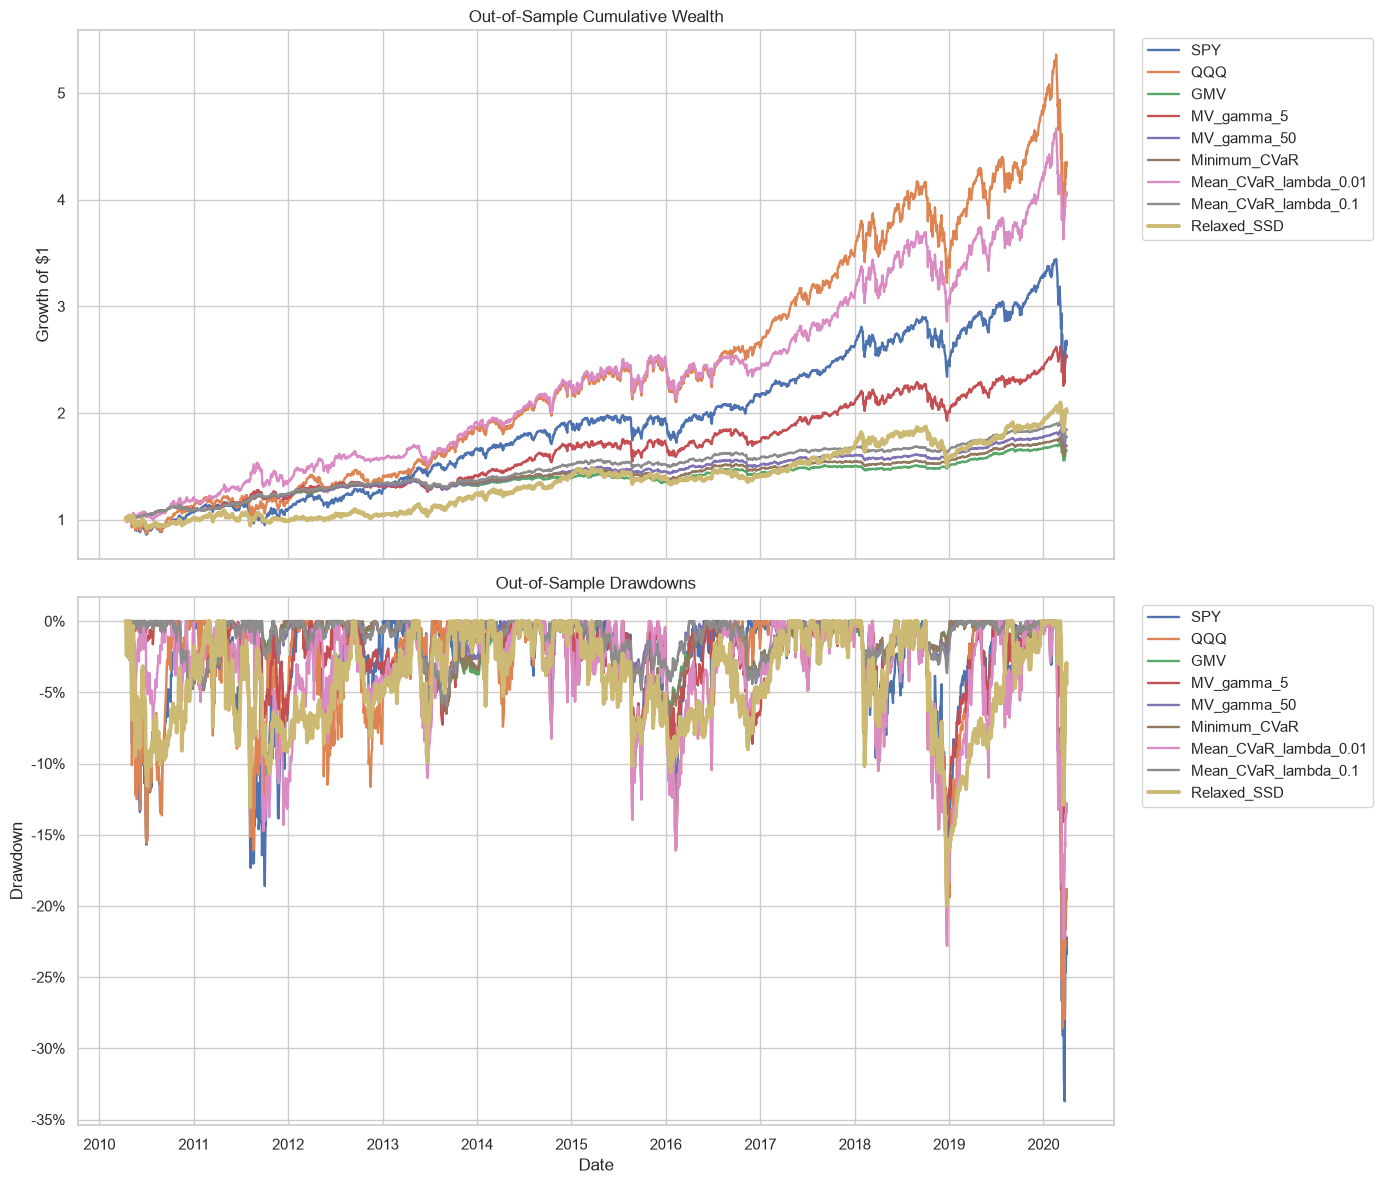

In [24]:
comparison_wealth = (
    1 + comparison_returns
).cumprod()

comparison_drawdowns = (
    comparison_wealth
    / comparison_wealth.cummax()
    - 1
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 12),
    sharex=True,
)

for strategy in (
    comparison_wealth.columns
):
    line_width = (
        2.8
        if strategy
        == "Relaxed_SSD"
        else 1.7
    )

    axes[0].plot(
        comparison_wealth.index,
        comparison_wealth[
            strategy
        ],
        label=strategy,
        linewidth=line_width,
    )

    axes[1].plot(
        comparison_drawdowns.index,
        comparison_drawdowns[
            strategy
        ],
        label=strategy,
        linewidth=line_width,
    )

axes[0].set_title(
    "Out-of-Sample Cumulative Wealth"
)

axes[0].set_ylabel(
    "Growth of $1"
)

axes[1].set_title(
    "Out-of-Sample Drawdowns"
)

axes[1].set_xlabel(
    "Date"
)

axes[1].set_ylabel(
    "Drawdown"
)

axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position:
            f"{value:.0%}"
    )
)

for axis in axes:
    axis.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

plt.tight_layout()
plt.show()

## Realized Risk–Return Comparison

The following figure compares each strategy's realized CAGR with its annualized
volatility. Portfolios toward the upper-left region are more desirable because
they combine higher realized growth with lower volatility.

This is an out-of-sample empirical comparison rather than an estimated
efficient frontier.

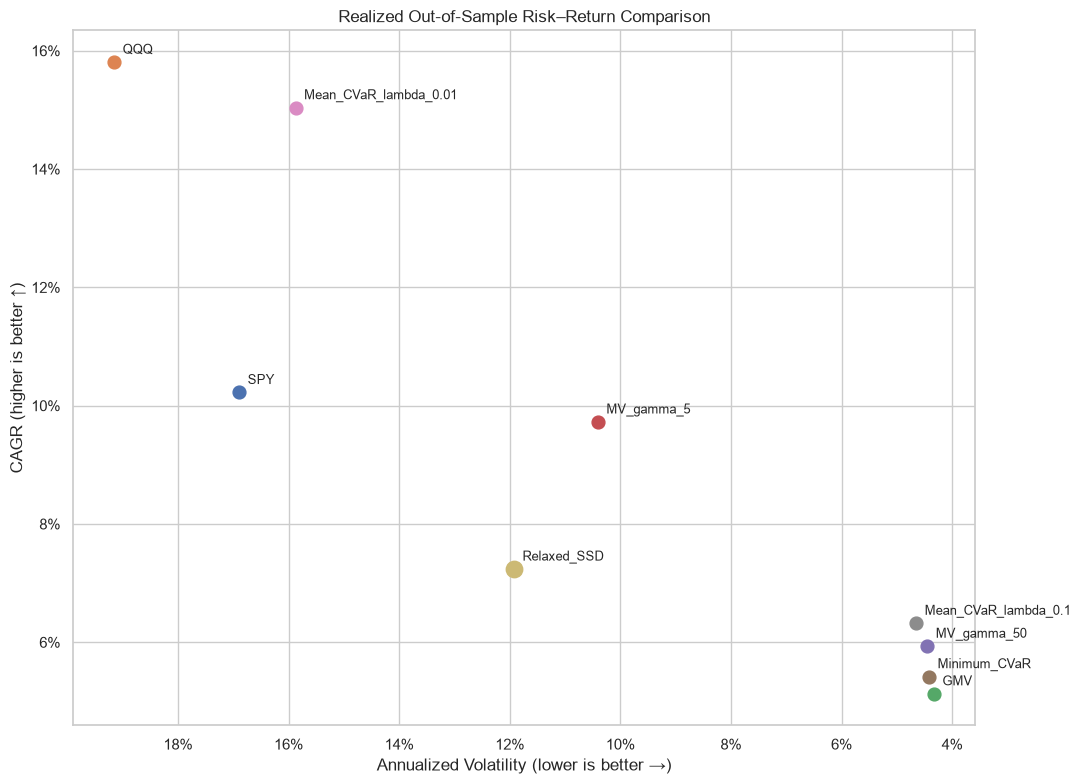

In [28]:
fig, ax = plt.subplots(
    figsize=(11, 8)
)

for strategy, row in (
    final_performance_summary
    .iterrows()
):
    marker_size = (
        140
        if strategy
        == "Relaxed_SSD"
        else 85
    )

    ax.scatter(
        row[
            "Annualized Volatility"
        ],
        row["CAGR"],
        s=marker_size,
    )

    ax.annotate(
        strategy,
        (
            row[
                "Annualized Volatility"
            ],
            row["CAGR"],
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position:
            f"{value:.0%}"
    )
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position:
            f"{value:.0%}"
    )
)

ax.set_title(
    "Realized Out-of-Sample "
    "Risk–Return Comparison"
)

ax.set_xlabel(
    "Annualized Volatility"
)

ax.set_ylabel(
    "CAGR"
)

ax.set_xlabel(
    "Annualized Volatility "
    "(lower is better →)"
)

ax.set_ylabel(
    "CAGR "
    "(higher is better ↑)"
)

ax.invert_xaxis()

plt.tight_layout()
plt.show()

### Realized Risk–Return Interpretation

The realized risk–return comparison reveals a clear progression from
high-return equity exposure to low-risk defensive portfolios.

QQQ produces the highest CAGR, but also has the highest annualized volatility.
The mean–CVaR portfolio with $\lambda=0.01$ achieves a similar CAGR with
materially lower volatility, making it a more attractive high-return
alternative over this backtest period.

The mean–variance portfolio with $\gamma=5$ produces approximately the same
CAGR as SPY while substantially reducing realized volatility. Consequently,
SPY is dominated by the $\gamma=5$ portfolio in the two-dimensional realized
CAGR–volatility comparison.

The selected relaxed-SSD portfolio does not lie on the realized risk–return
frontier. In particular, the $\gamma=5$ mean–variance portfolio achieves both a
higher CAGR and lower volatility. This indicates that the maximum-weight
constraint substantially improves the original relaxed-SSD strategy, but does
not make it competitive with the strongest conventional optimization models.

Within the low-risk region, the mean–CVaR portfolio with $\lambda=0.1$, the
mean–variance portfolio with $\gamma=50$, the minimum-CVaR portfolio, and the
GMV portfolio represent progressively more conservative choices. Moving toward
the right side of the figure reduces volatility but also lowers realized
growth.

The dominance relationships discussed here refer only to the two-dimensional
CAGR–volatility plane. They should not be confused with first- or second-order
stochastic dominance, which compares the complete return distributions.

## Realized Return–Tail-Risk Comparison

This figure compares realized CAGR with empirical daily CVaR measured over the
worst 5% of daily returns.

CVaR is reported as a positive loss magnitude. The horizontal axis is reversed
so that portfolios with lower tail loss appear farther to the right. Therefore,
portfolios closer to the upper-right corner combine higher compounded return
with lower realized tail risk.

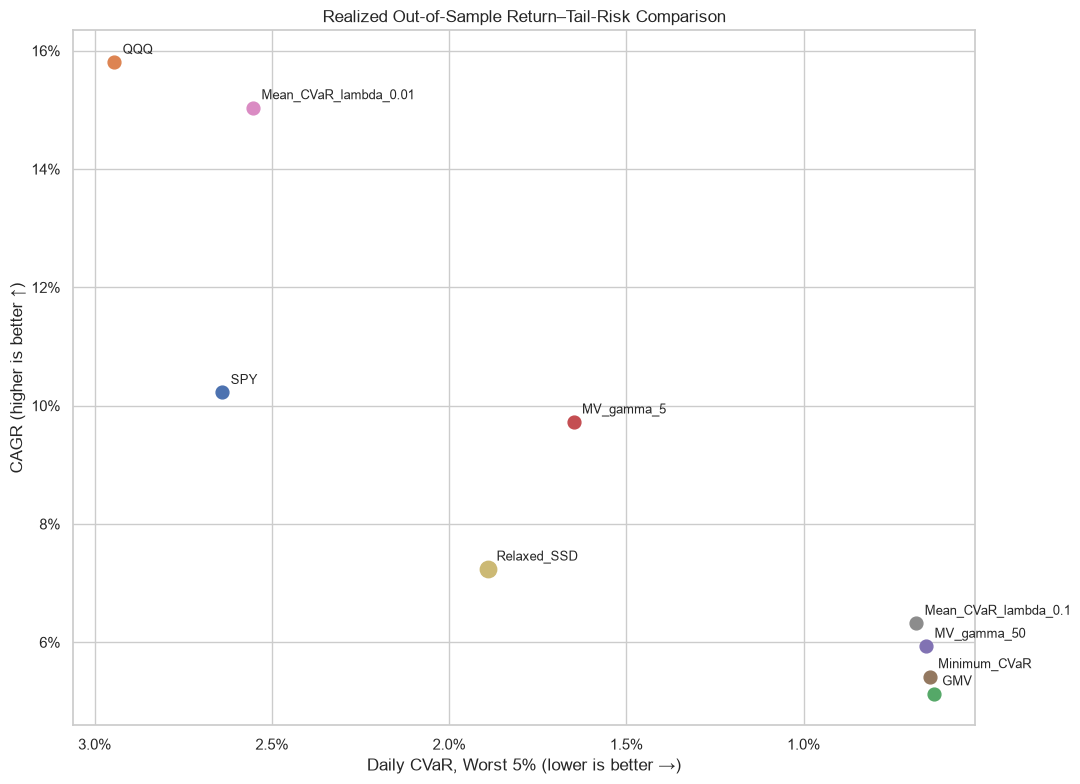

In [29]:
fig, ax = plt.subplots(
    figsize=(11, 8)
)

for strategy, row in (
    final_performance_summary
    .iterrows()
):
    marker_size = (
        140
        if strategy
        == "Relaxed_SSD"
        else 85
    )

    ax.scatter(
        row[
            "Daily 95% CVaR"
        ],
        row["CAGR"],
        s=marker_size,
    )

    ax.annotate(
        strategy,
        (
            row[
                "Daily 95% CVaR"
            ],
            row["CAGR"],
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position:
            f"{value:.1%}"
    )
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position:
            f"{value:.0%}"
    )
)

ax.set_title(
    "Realized Out-of-Sample "
    "Return–Tail-Risk Comparison"
)

ax.set_xlabel(
    "Daily CVaR, Worst 5% "
    "(lower is better →)"
)

ax.set_ylabel(
    "CAGR "
    "(higher is better ↑)"
)

ax.invert_xaxis()

plt.tight_layout()
plt.show()

### Practical Role and Limitation of SSD

Second-order stochastic dominance provides a stronger distributional comparison
than variance or CVaR at a single confidence level. If portfolio return $X$
second-order stochastically dominates benchmark return $Y$, then

$$
E[u(X)] \geq E[u(Y)]
$$

for every increasing and concave utility function $u$. Equivalently, the
portfolio has no greater expected shortfall than the benchmark at every return
threshold. Thus, SSD does not require selecting one particular risk-aversion
coefficient or tail probability.

However, this theoretical guarantee applies to the underlying return
distributions. In the empirical portfolio problem, these distributions are
unknown and are replaced by historical observations. The optimizer can
therefore exploit sampling noise and identify a portfolio that approximately
dominates the benchmark in sample but does not preserve this relation out of
sample.

The unconstrained relaxed-SSD portfolios in this study are especially
concentrated and perform poorly out of sample. A maximum-weight constraint
substantially improves their realized risk and return, demonstrating the value
of regularization. Nevertheless, the selected relaxed-SSD strategy remains
dominated by the $\gamma=5$ mean–variance strategy in both the realized
CAGR–volatility and CAGR–CVaR comparisons.

Consequently, SSD is valuable in this project as a distribution-wide risk
framework and as a diagnostic of estimation error, but it does not produce the
best realized investment strategy in this particular backtest.